# Eukaryotic functional annotation analysis

Functional descriptions are compared to the mitochondrial-free NCBI RefSeq reference by exact `RNA_ID`; lowercase `protein_id` is retained as sequence provenance. Missing, empty, `-`, and vague descriptions are non-informative. `Both Informative` does not assert biological equivalence.

The primary comparison restricts the reference to RNA_ID values present in the GFFread FASTA, selects the first submitted transcript per locus, and retains only records returned by all four tools. Canonical proteins are evaluated separately in the final section using reviewed Swiss-Prot records, an exact versioned RefSeq `protein_id` cross-reference, and an exact NCBI FAA amino-acid sequence match.

In [1]:
import pandas as pd

from benchannot.eukaryotic.canonical_mapping import (
    build_canonical_functional_table,
    build_coverage_table,
    ensure_uniprot_cache,
    load_uniprot_cache,
    plot_canonical_coverage,
    read_fasta_ids,
    read_reference_faa,
    resolve_canonical_loci,
)
from benchannot.eukaryotic.functional_analysis import (
    add_reference_baseline,
    categorize_functional_shifts,
    plot_functional_shift_panels,
    plot_functional_shifts,
    prepare_reference_descriptions,
    select_common_tool_hits,
    select_first_submitted_transcript,
)
from benchannot.paths import project_paths, validate_required_inputs

In [2]:
DATASET = "origin"  # "origin" or "reproduced"
PATHS = project_paths(DATASET)

EUKARYOTIC_OUTPUT = PATHS.analysis_output / "eukaryotic"
ANALYSIS_DIR = EUKARYOTIC_OUTPUT / "functional_analysis"
TABLE_DIR = ANALYSIS_DIR / "tables"
PLOT_DIR = ANALYSIS_DIR / "plots"
CACHE_DIR = ANALYSIS_DIR / "uniprot_cache"

TOOLS = ['Kofam', 'Pannzer', 'EggNOG', 'InterProScan']
ORGANISMS = [
    {
        'organism': 'saccharomyces_cerevisiae',
        'display_name': 'Saccharomyces cerevisiae',
        'plot_name': r'$\mathit{S.\ cerevisiae}$',
        'proteome_id': 'UP000002311',
    },
    {
        'organism': 'drosophila_melanogaster',
        'display_name': 'Drosophila melanogaster',
        'plot_name': r'$\mathit{D.\ melanogaster}$',
        'proteome_id': 'UP000000803',
    },
]
for config in ORGANISMS:
    organism = config['organism']
    config['functional_table'] = (
        EUKARYOTIC_OUTPUT / 'tool_preparation' / 'tables'
        / f'{organism}_functional_annotations.tsv'
    )
    config['reference_faa'] = (
        PATHS.genome_eukaryote / f'{organism}.faa'
    )
    config['submitted_faa'] = (
        PATHS.eukaryote_tools / 'gffread' / f'{organism}_gffread.faa'
    )
    config['cache'] = CACHE_DIR / f"{organism}_{config['proteome_id']}.json"

CONFIG_BY_ORGANISM = {
    config['organism']: config
    for config in ORGANISMS
}

print(f"Dataset: {DATASET}")
print(f"Tool inputs: {PATHS.eukaryote_tools}")
print(f"Analysis outputs: {ANALYSIS_DIR}")


In [ ]:
functional_table_inputs = {
    f"{config['organism']} functional annotations": config["functional_table"]
    for config in ORGANISMS
}

validate_required_inputs(
    functional_table_inputs,
    context=f"eukaryotic functional-table loading ({DATASET})",
)

for directory in (TABLE_DIR, PLOT_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


In [3]:
functional_tables = {}
required_columns = {
    'RNA_ID', 'protein_id', 'locus_tag', 'Reference', *TOOLS,
    *(f'{tool}_returned' for tool in TOOLS),
}
for config in ORGANISMS:
    table = pd.read_csv(config['functional_table'], sep='\t')
    missing = required_columns - set(table.columns)
    if missing:
        raise ValueError(f"{config['functional_table']} is missing {sorted(missing)}")
    functional_tables[config['organism']] = prepare_reference_descriptions(table)
    table = functional_tables[config['organism']]
    print(f"{config['display_name']}: {len(table):,} RNA_ID, {table['locus_tag'].nunique():,} loci")
    print(table[TOOLS].notna().sum().rename('non-null descriptions').to_string())

Saccharomyces cerevisiae: 6,002 RNA_ID, 6,002 loci
Kofam           3629
Pannzer         5358
EggNOG          5495
InterProScan    4791
Drosophila melanogaster: 30,789 RNA_ID, 13,973 loci
Kofam           16563
Pannzer         26382
EggNOG          28408
InterProScan    25147


## Submitted first-transcript functional comparison

The primary functional universe contains only RNA_ID values present in the GFFread FASTA, with the first submitted transcript selected for each locus. The comparison then retains only proteins returned by Kofam, Pannzer, EggNOG, and InterProScan; Kofam presence comes from significant hits. Tool descriptions are classified against the NCBI RefSeq description for this common universe.

In [ ]:
drosophila_config = CONFIG_BY_ORGANISM["drosophila_melanogaster"]
validate_required_inputs(
    {
        f"drosophila_melanogaster GFFread submitted FAA ({DATASET})":
            drosophila_config["submitted_faa"],
    },
    context=f"eukaryotic Drosophila submitted-transcript analysis ({DATASET})",
)


In [ ]:
# Keep one submitted Drosophila transcript per locus, including tool no-hits.
organism = 'drosophila_melanogaster'
submitted_faa = drosophila_config['submitted_faa']
submitted_ids = read_fasta_ids(submitted_faa)
submitted_first = select_first_submitted_transcript(
    functional_tables[organism], submitted_ids
)
observed = (
    len(submitted_first),
    submitted_first['RNA_ID'].nunique(),
    submitted_first['locus_tag'].nunique(),
)
expected = (13_885, 13_885, 13_885)
if observed != expected:
    raise ValueError(f'{organism}: expected {expected}, observed {observed}')

submitted_first_path = TABLE_DIR / f'{organism}_submitted_first_transcript_input.tsv'
submitted_first.to_csv(submitted_first_path, sep='\t', index=False)
hit_summary = pd.DataFrame(
    {
        'identified': [int(submitted_first[f'{tool}_returned'].sum()) for tool in TOOLS],
        'not_identified': [int((~submitted_first[f'{tool}_returned']).sum()) for tool in TOOLS],
    },
    index=TOOLS,
)
print(
    f'Saved {len(submitted_first):,} RNA_ID across '
    f'{submitted_first["locus_tag"].nunique():,} loci to {submitted_first_path}'
)
print(hit_summary.to_string())

In [ ]:
common_submitted_inputs = {
    f"{config['organism']} GFFread submitted FAA ({DATASET})":
        config["submitted_faa"]
    for config in ORGANISMS
}

validate_required_inputs(
    common_submitted_inputs,
    context=f"eukaryotic common submitted-tool analysis ({DATASET})",
)


In [ ]:
# Restrict the reference to GFFread proteins before selecting one transcript per locus.
common_functional_panels = {}
for panel, config in zip(('A', 'B'), ORGANISMS, strict=True):
    organism = config['organism']
    submitted_faa = config['submitted_faa']
    submitted_ids = read_fasta_ids(submitted_faa)
    submitted_all = functional_tables[organism].loc[
        functional_tables[organism]['RNA_ID'].isin(submitted_ids)
    ].copy()

    if organism == 'drosophila_melanogaster':
        removed_count = len(functional_tables[organism]) - len(submitted_all)
        observed = (
            len(submitted_all),
            submitted_all['RNA_ID'].nunique(),
            submitted_all['locus_tag'].nunique(),
            removed_count,
        )
        expected = (30_073, 30_073, 13_885, 716)
        if observed != expected:
            raise ValueError(f'{organism}: expected {expected}, observed {observed}')
        submitted_all_path = TABLE_DIR / f'{organism}_submitted_all_RNA_ID_input.tsv'
        submitted_all.to_csv(submitted_all_path, sep='\t', index=False)
        print(
            f'{config["display_name"]}: saved {len(submitted_all):,} submitted RNA_ID '
            f'across {submitted_all["locus_tag"].nunique():,} loci to {submitted_all_path}'
        )

    submitted_first = select_first_submitted_transcript(
        submitted_all, submitted_ids
    )
    returned_columns = [f'{tool}_returned' for tool in TOOLS]
    reference_only = submitted_first.loc[
        ~submitted_first[returned_columns].any(axis=1)
    ].copy()
    if len(reference_only) != reference_only['locus_tag'].nunique():
        raise ValueError(f'{organism}: reference-only table contains duplicate loci')
    reference_only_path = (
        TABLE_DIR / f'{organism}_submitted_first_transcript_reference_only.tsv'
    )
    reference_only.to_csv(reference_only_path, sep='\t', index=False)
    print(
        f'{config["display_name"]}: saved {len(reference_only):,} reference-only loci '
        f'to {reference_only_path}'
    )
    common = select_common_tool_hits(submitted_first, TOOLS)
    if not common['RNA_ID'].isin(submitted_ids).all():
        raise ValueError(f'{organism}: functional universe contains RNA_ID absent from GFFread')
    if len(common) != common['locus_tag'].nunique():
        raise ValueError(f'{organism}: functional universe contains duplicate loci')

    summary, details = categorize_functional_shifts(common, TOOLS)
    plot_input = add_reference_baseline(summary, common)
    suffix = 'submitted_first_transcript_common_tools'
    common.to_csv(TABLE_DIR / f'{organism}_{suffix}_input.tsv', sep='\t', index=False)
    plot_input.rename_axis('Source').reset_index().to_csv(
        TABLE_DIR / f'{organism}_{suffix}_summary.tsv', sep='\t', index=False
    )
    details.to_csv(
        TABLE_DIR / f'{organism}_{suffix}_details.tsv', sep='\t', index=False
    )
    display_math = config['display_name'].replace(' ', r'\ ')
    common_functional_panels[rf'{panel}) $\it{{{display_math}}}$'] = plot_input
    print(f"\n{panel}) {config['display_name']}: {len(common):,} proteins")
    print(plot_input.to_string())

common_functional_path = PLOT_DIR / 'eukaryotic_submitted_common_tools_functional.png'
plot_functional_shift_panels(
    common_functional_panels,
    'Functional Annotation Comparison against Ground Truth',
    common_functional_path,
    count_label='Protein',
)
print(f'\nSaved {common_functional_path}')

## Reviewed Swiss-Prot canonical analysis

Only uniquely resolved canonical protein sequences enter the functional denominator. Equivalent exact transcripts retain a tie status and use NCBI RefSeq order for plotting. Ambiguity, conflicts, and absent reviewed mappings never trigger fallback. A canonical RNA absent from submitted input remains in the denominator with missing tool annotations.

In [ ]:
canonical_inputs = {}
for config in ORGANISMS:
    organism = config["organism"]
    canonical_inputs.update(
        {
            f"{organism} reference FAA": config["reference_faa"],
            f"{organism} submitted GFFread FAA ({DATASET})": config["submitted_faa"],
        }
    )

validate_required_inputs(
    canonical_inputs,
    context=f"eukaryotic canonical analysis ({DATASET})",
)



Saccharomyces cerevisiae Swiss-Prot canonical statuses
resolution_status
resolved_canonical     5823
no_reviewed_mapping     156
sequence_conflict        23

Submission status among uniquely resolved canonical loci
submission_status
submitted    5823

Coverage plotted
               Source  RNA_ID count  Represented loci  Recovered canonical RNA_ID
NCBI RefSeq reference          6002              6002                        5823
                Kofam          3629              3629                        3584
              Pannzer          5358              5358                        5252
               EggNOG          5495              5495                        5355
         InterProScan          4791              4791                        4683

Canonical functional plot input
                       Both Informative  Both Hypothetical  Over-Annotation  Under-Annotation
NCBI RefSeq reference              5053                770                0                 0
EggNOG           

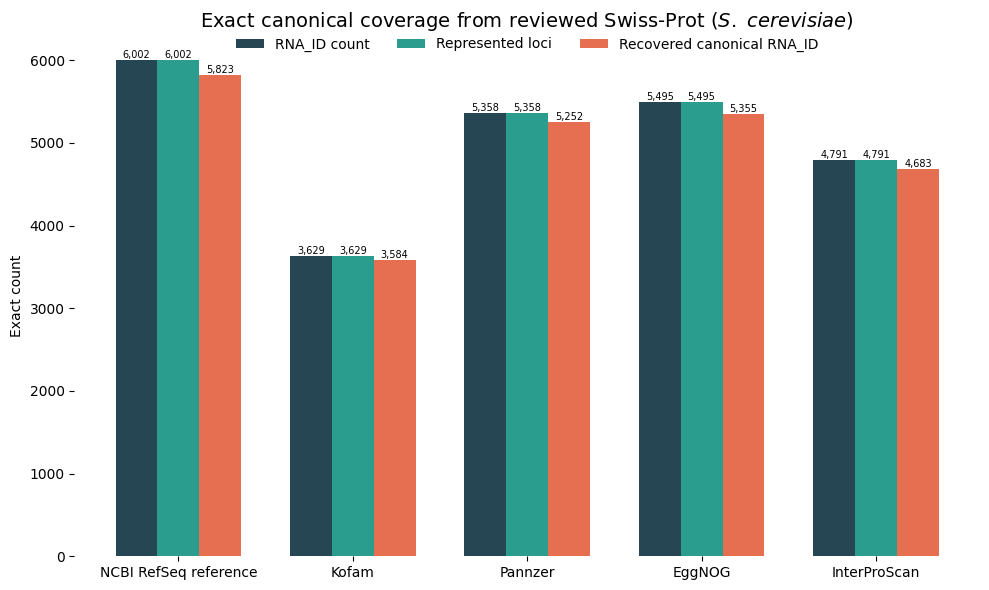

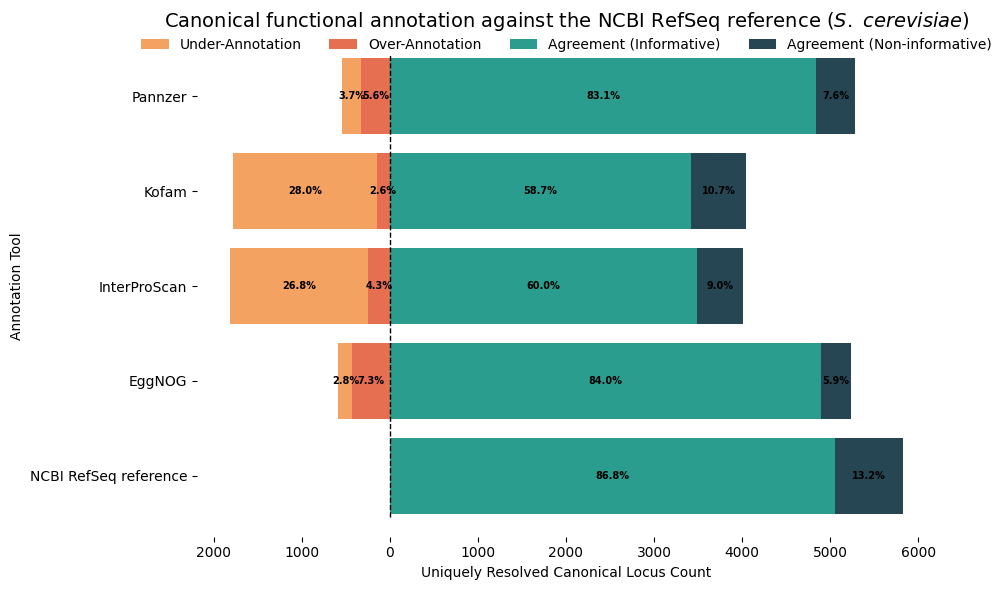


Drosophila melanogaster Swiss-Prot canonical statuses
resolution_status
no_reviewed_mapping            10053
resolved_canonical              2386
equivalent_transcript_tie       1461
sequence_conflict                 52
ambiguous_reviewed_isoforms       21

Submission status among uniquely resolved canonical loci
submission_status
submitted                  3818
canonical_not_submitted      29

Coverage plotted
               Source  RNA_ID count  Represented loci  Recovered canonical RNA_ID
NCBI RefSeq reference         30789             13973                        3847
                Kofam         16563              7134                        2951
              Pannzer         26382             11715                        3536
               EggNOG         28408             12653                        3736
         InterProScan         25147             10990                        3538

Canonical functional plot input
                       Both Informative  Both Hypothetical 

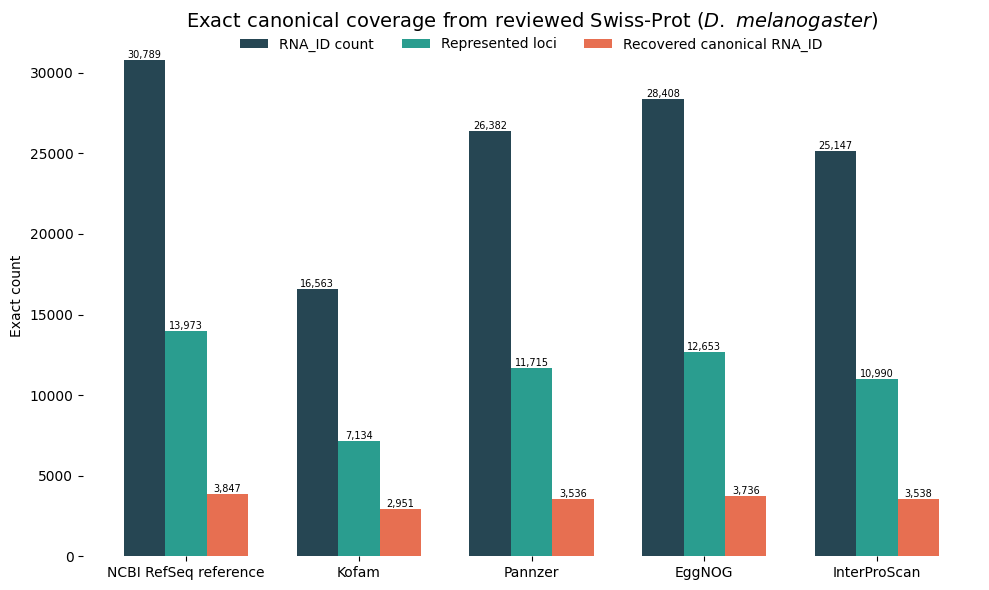

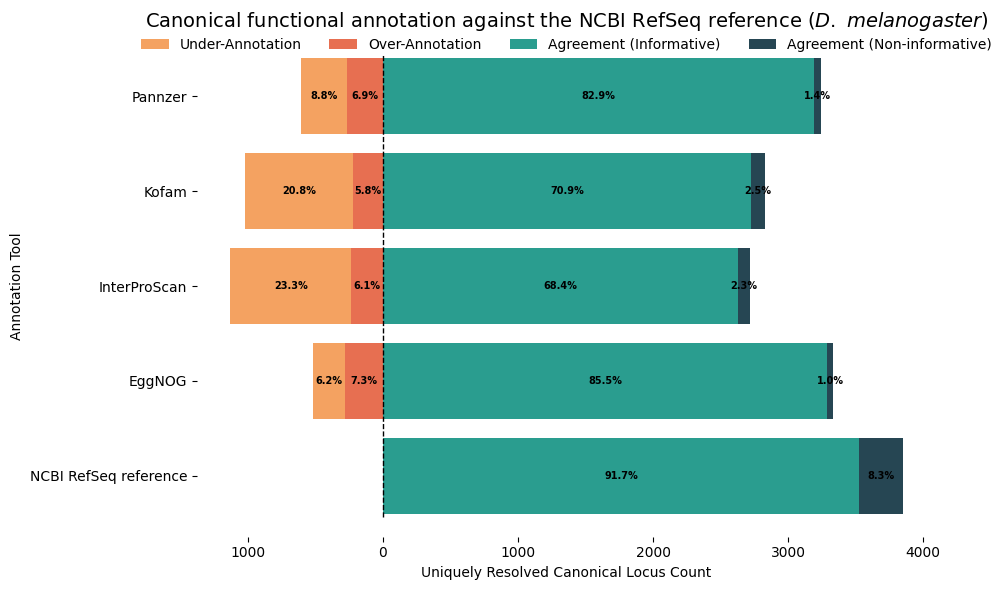

In [6]:
for config in ORGANISMS:
    organism = config['organism']
    cache_path = ensure_uniprot_cache(config['proteome_id'], config['cache'])
    cache_payload = load_uniprot_cache(cache_path, config['proteome_id'])
    faa_sequences = read_reference_faa(config['reference_faa'])
    submitted_ids = read_fasta_ids(config['submitted_faa'])
    table = functional_tables[organism]
    mapping, selection = resolve_canonical_loci(
        table, faa_sequences, cache_payload, submitted_rna_ids=submitted_ids
    )
    canonical = build_canonical_functional_table(table, selection)
    coverage = build_coverage_table(table, selection, TOOLS)
    summary, details = categorize_functional_shifts(canonical, TOOLS)
    plot_input = add_reference_baseline(summary, canonical)

    mapping.to_csv(TABLE_DIR / f'{organism}_canonical_mapping.tsv', sep='\t', index=False)
    selection.to_csv(TABLE_DIR / f'{organism}_canonical_selection.tsv', sep='\t', index=False)
    coverage.to_csv(TABLE_DIR / f'{organism}_canonical_coverage.tsv', sep='\t', index=False)
    canonical.to_csv(TABLE_DIR / f'{organism}_canonical_functional_input.tsv', sep='\t', index=False)
    plot_input.rename_axis('Source').reset_index().to_csv(
        TABLE_DIR / f'{organism}_canonical_functional_summary.tsv', sep='\t', index=False
    )
    details.to_csv(
        TABLE_DIR / f'{organism}_canonical_functional_details.tsv', sep='\t', index=False
    )

    print(f"\n{config['display_name']} Swiss-Prot canonical statuses")
    print(mapping.drop_duplicates('locus_tag')['resolution_status'].value_counts().to_string())
    print('\nSubmission status among uniquely resolved canonical loci')
    print(selection['submission_status'].value_counts().to_string())
    print('\nCoverage plotted')
    print(coverage.to_string(index=False))
    print('\nCanonical functional plot input')
    print(plot_input.to_string())

    plot_canonical_coverage(
        coverage,
        f"Exact canonical coverage from reviewed Swiss-Prot ({config['plot_name']})",
        PLOT_DIR / f'{organism}_canonical_coverage.png',
    )
    plot_functional_shifts(
        plot_input,
        f"Canonical functional annotation against the NCBI RefSeq reference ({config['plot_name']})",
        PLOT_DIR / f'{organism}_canonical_functional.png',
        count_label='Uniquely Resolved Canonical Locus',
    )